## Task 6 – Time Series Classification
### Objective
The objective of Task 6 is to evaluate whether ECG time‑series data alone can be used to discriminate between ischemic and non‑ischemic cardiovascular conditions.
Only ECG‑derived representations are used as model inputs, while clinical labels are employed exclusively as ground truth.

Each patient is represented by a univariate ECG time series obtained via Piecewise Aggregate Approximation (PAA), ensuring consistent length and reduced noise.

## Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


## Load ECG Time Series and Labels

## Data and Labels
The ECG time‑series dataset is merged with clinical labels extracted from the tabular data.
The binary target variable ischemic_disease is defined as:

- Class 1: At least one ischemic diagnosis (ICD‑10 I20–I25)
- Class 0: All other cardiovascular conditions

No tabular features are used for model training.

In [2]:
df_paa = pd.read_csv("../3/data/ecg_paa.csv")
labels_df = pd.read_csv("../4/data/patient_profiles_with_labels.csv")

df = df_paa.merge(labels_df[['subject_id', 'ischemic_disease']], on='subject_id')

X = df.drop(columns=['subject_id', 'hadm_id', 'ischemic_disease'])
y = df['ischemic_disease']

## Train/Test Split (Patient‑Level)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

## Preprocessing
- Standardization is applied to ECG features for models that rely on distance‑based or gradient‑based optimization (Logistic Regression and Gradient Boosting).
- Tree‑based models (Random Forest) are trained on unscaled data.

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training & Evaluation
## Classification Models
Three supervised classifiers are evaluated:

- Logistic Regression (linear baseline, interpretable)
- Random Forest (non‑linear ensemble model)
- Gradient Boosting (boosted decision trees)

Class weights are used where appropriate to mitigate class imbalance.

In [5]:
def evaluate_model(name, model, Xtr, Xte):
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]

    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

## Model 1 — Logistic Regression

In [6]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
res_lr = evaluate_model("Logistic Regression", lr,
                        X_train_scaled, X_test_scaled)

## Model 2 — Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced'
)

res_rf = evaluate_model("Random Forest", rf,
                        X_train, X_test)

## Model 3 — Gradient Boosting

In [8]:
gb = GradientBoostingClassifier(random_state=42)

res_gb = evaluate_model("Gradient Boosting", gb,
                        X_train_scaled, X_test_scaled)

## Performance Metrics
Model performance is evaluated using:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1‑score
- ROC‑AUC

Metrics are computed on the held‑out test set.

## Results Summary Table
The table below reports the classification performance for all evaluated models.

In [9]:
results_df = pd.DataFrame([res_lr, res_rf, res_gb])
results_df

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.496622,0.495614,0.481752,0.458333,0.469751,0.483553
1,Random Forest,0.462838,0.461257,0.442748,0.402778,0.421818,0.460458
2,Gradient Boosting,0.489865,0.487208,0.470588,0.388889,0.425856,0.485060


## Confusion Matrices

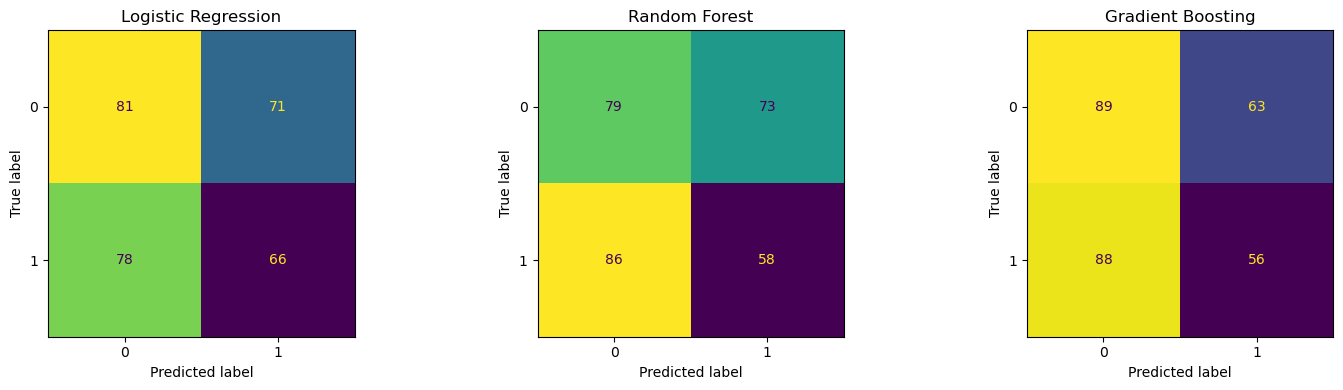

In [10]:
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb
}

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(
        X_test_scaled if name != "Random Forest" else X_test
    )
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

## ROC Curve Analysis
Receiver Operating Characteristic (ROC) curves show that all classifiers closely follow the diagonal, confirming limited discriminative power when relying exclusively on ECG time‑series data.

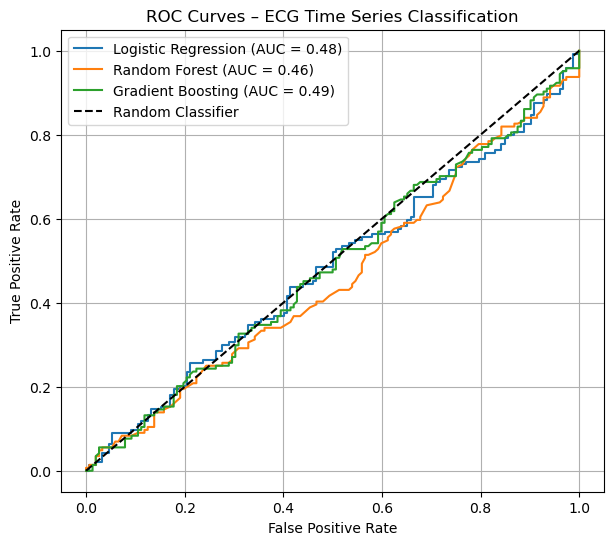

In [11]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7,6))

for name, model in models.items():
    if name == "Random Forest":
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--', label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – ECG Time Series Classification")
plt.legend()
plt.grid(True)
plt.show()

## Precision–Recall Analysis
Precision–Recall curves further highlight the difficulty of the task, with precision rapidly decreasing as recall increases.
This behavior is typical in medical classification problems where the signal‑to‑noise ratio is low.

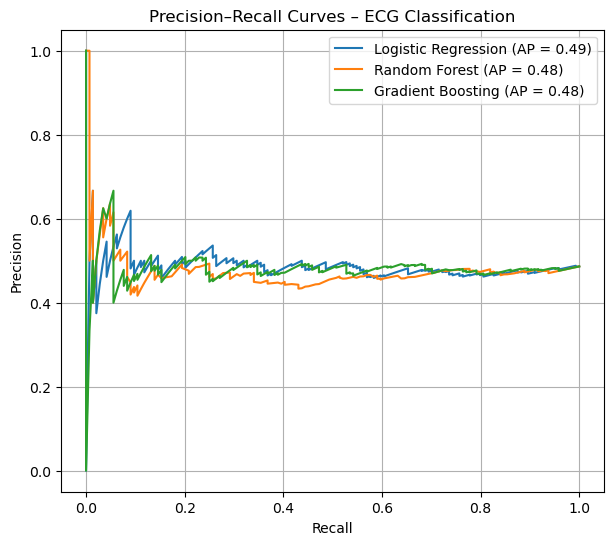

In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(7,6))

for name, model in models.items():
    if name == "Random Forest":
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    plt.plot(recall, precision, label=f"{name} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves – ECG Classification")
plt.legend()
plt.grid(True)
plt.show()

## Model Comparison
A direct comparison of evaluation metrics shows no clear dominant model.
Random Forest and Gradient Boosting marginally outperform Logistic Regression on some metrics, but differences remain small.

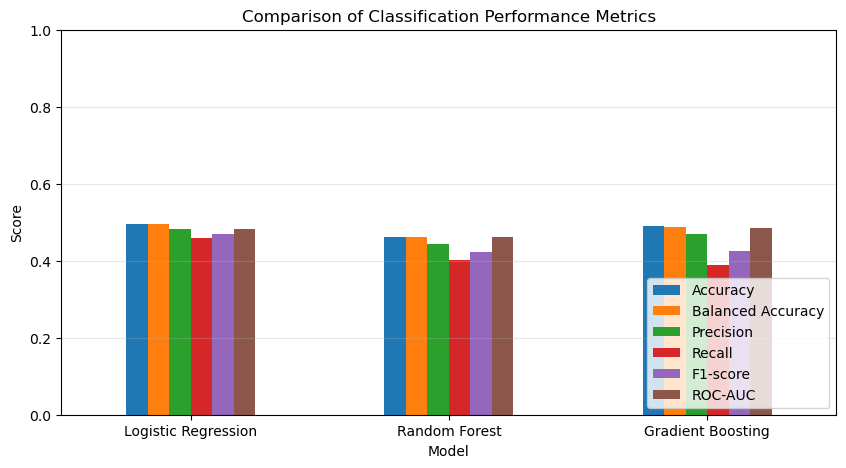

In [13]:
results_df.set_index("Model")[[
    "Accuracy", "Balanced Accuracy", "Precision",
    "Recall", "F1-score", "ROC-AUC"
]].plot(kind="bar", figsize=(10,5))

plt.title("Comparison of Classification Performance Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc="lower right")
plt.show()

## Distribution of Predicted Probabilities

To better understand the behavior of the classification models, we analyze the
distribution of predicted probabilities for ischemic and non‑ischemic patients.

This analysis provides insight into how confidently each model separates the two
classes and helps explain the observed performance metrics beyond accuracy and ROC‑AUC.

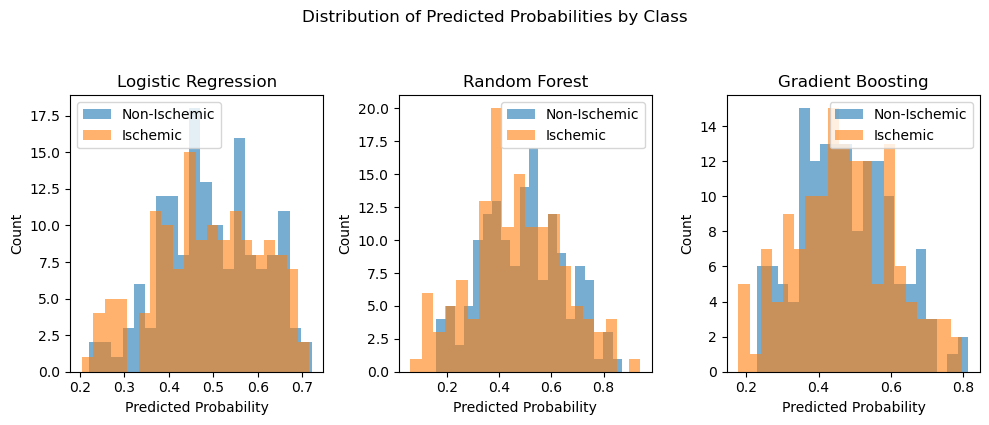

In [14]:
plt.figure(figsize=(10,4))

for i, (name, model) in enumerate(models.items(), 1):
    plt.subplot(1, 3, i)

    if name == "Random Forest":
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    plt.hist(y_prob[y_test == 0], bins=20, alpha=0.6, label="Non-Ischemic")
    plt.hist(y_prob[y_test == 1], bins=20, alpha=0.6, label="Ischemic")

    plt.title(name)
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.legend()

plt.suptitle("Distribution of Predicted Probabilities by Class", y=1.05)
plt.tight_layout()
plt.show()

### Bias–Variance Assessment
Learning curves indicate that both training and validation ROC‑AUC converge toward values close to 0.5 as the training size increases.

This suggests that poor performance is due to limited informativeness of the ECG representation rather than model overfitting.

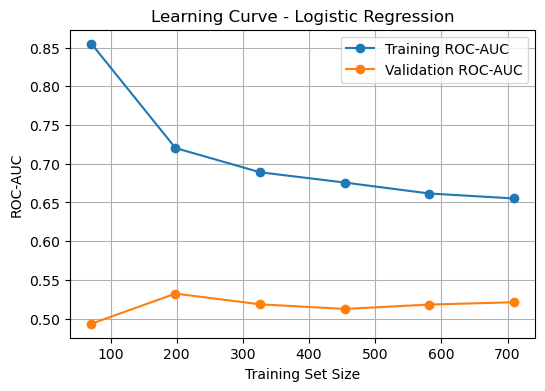

In [15]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000, class_weight='balanced'),
    X_train_scaled, y_train,
    cv=5,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 6)
)

plt.figure(figsize=(6,4))
plt.plot(train_sizes, train_scores.mean(axis=1), marker='o', label="Training ROC-AUC")
plt.plot(train_sizes, val_scores.mean(axis=1), marker='o', label="Validation ROC-AUC")
plt.xlabel("Training Set Size")
plt.ylabel("ROC-AUC")
plt.title("Learning Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
preds = pd.DataFrame({
    "LR": lr.predict(X_test_scaled),
    "RF": rf.predict(X_test),
    "GB": gb.predict(X_test_scaled),
    "True": y_test.values
})

agreement = preds[['LR','RF','GB']].mode(axis=1)[0]
agreement_accuracy = (agreement == preds['True']).mean()

agreement_accuracy

0.49324324324324326

## Bonus Section: Tabular data incorporation into Task 6

In [43]:
# Load tabular features
tabular_df = pd.read_csv("../4/Data/patient_profiles_with_labels.csv")

TABULAR_FEATURES = [
    "age",
    "total_tests",
    "k_abnormal_ratio"
]

tabular_df = tabular_df[
    ["subject_id", "ischemic_disease"] + TABULAR_FEATURES
].rename(columns={"ischemic_disease": "label"})

# ECG PAA features (already include subject_id)
paa_df = df_paa.copy()

# Merge ECG + tabular
merged_df = paa_df.merge(tabular_df, on="subject_id", how="inner")

merged_df = merged_df.drop(columns="hadm_id")

merged_df.head()

,subject_id,paa_0,paa_1,paa_2,paa_3,paa_4,paa_5,paa_6,paa_7,paa_8,...,paa_94,paa_95,paa_96,paa_97,paa_98,paa_99,label,age,total_tests,k_abnormal_ratio
0,12654170,-0.261968,1.057864,-0.066086,-1.367814,-0.050679,0.207326,0.440811,-1.313622,0.233686,...,-0.237216,0.077774,0.904949,-0.841221,0.460221,0.113098,0,79.0,668.0,0.038
1,12839165,-0.310558,-0.352318,-0.011020,-0.248382,1.692810,-0.017746,0.097254,-0.227767,-0.257030,...,1.292320,-0.235464,-0.485437,-0.468800,-0.310749,-0.225291,1,64.0,57.0,0.000
2,11469226,0.074416,0.603636,1.018793,-0.220347,-0.579263,-0.822623,-1.378075,0.093772,0.199782,...,0.223941,0.280723,0.354127,0.412462,0.698872,1.575375,1,68.0,15.0,1.000
3,16941887,0.797821,0.719604,-1.054281,0.171213,-0.143464,-0.136284,-0.802779,-0.976228,-0.779892,...,0.297749,0.165439,0.547009,-0.233869,-0.284694,0.009891,0,73.0,74.0,0.500
4,19968075,0.096778,0.658912,-0.007269,0.549369,-0.260444,-0.394247,-0.063551,0.062189,0.774704,...,-0.419029,-0.061826,0.095218,0.566237,0.122907,0.509533,1,61.0,354.0,0.500


In [44]:
print("Merged shape:", merged_df.shape)
print("Missing values:\n", merged_df.isna().sum().sum())

Merged shape: (1184, 105)
Missing values:
 2


In [45]:
merged_df = merged_df.dropna()

print("After removal shape:", merged_df.shape)
print("Missing values:\n", merged_df.isna().sum().sum())

After removal shape: (1183, 105)
Missing values:
 0


In [46]:
X_ts_only = merged_df.drop(
    columns=["subject_id", "label"] + TABULAR_FEATURES
)

X_ts_tab = merged_df.drop(
    columns=["subject_id", "label"]
)

y = merged_df["label"]

In [47]:
Xts_tr, Xts_te, y_tr, y_te = train_test_split(
    X_ts_only,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Xmix_tr, Xmix_te, _, _ = train_test_split(
    X_ts_tab,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
clf_ts = LogisticRegression(max_iter=1000)
clf_mix = LogisticRegression(max_iter=1000)

clf_ts.fit(Xts_tr, y_tr)
clf_mix.fit(Xmix_tr, y_tr)

In [49]:
results = []

for name, clf, Xte in [
    ("Time-series only", clf_ts, Xts_te),
    ("Time-series + tabular", clf_mix, Xmix_te)
]:
    y_pred = clf.predict(Xte)
    y_prob = clf.predict_proba(Xte)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_te, y_pred),
        "F1-score": f1_score(y_te, y_pred),
        "ROC-AUC": roc_auc_score(y_te, y_prob)
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1-score,ROC-AUC
0,Time-series only,0.531646,0.478873,0.502780
1,Time-series + tabular,0.502110,0.458716,0.527512


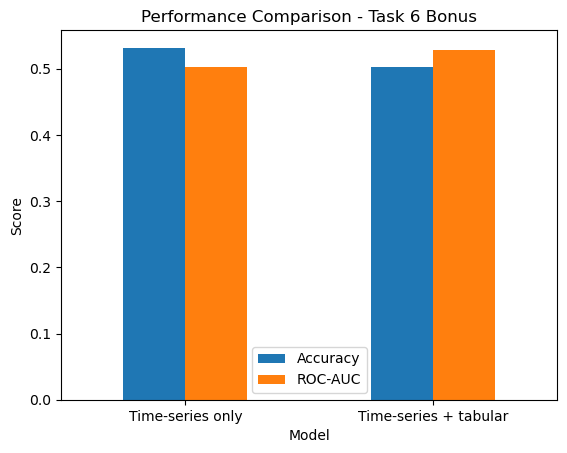

In [50]:
results_df.set_index("Model")[["Accuracy", "ROC-AUC"]].plot(
    kind="bar"
)
plt.title("Performance Comparison - Task 6 Bonus")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


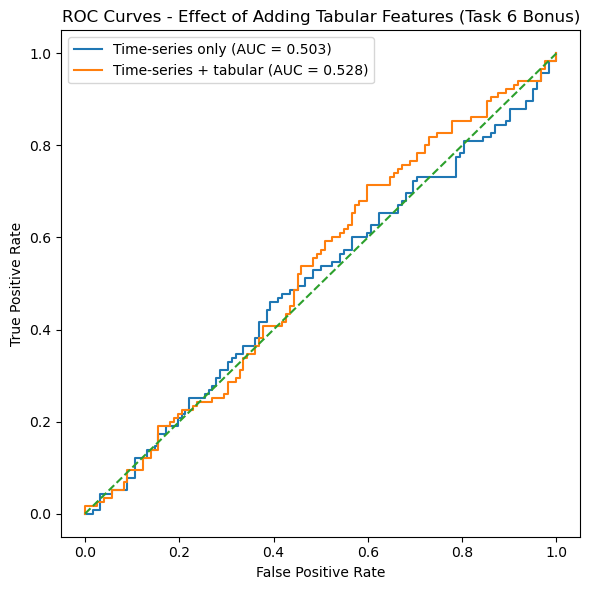

In [59]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(6, 6))

for name, clf, Xte in [
    ("Time-series only", clf_ts, Xts_te),
    ("Time-series + tabular", clf_mix, Xmix_te)
]:
    y_prob = clf.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Effect of Adding Tabular Features (Task 6 Bonus)")
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd

# Create a dataframe of coefficients
coef_df = pd.DataFrame({
    "feature": X_ts_tab.columns,
    "coefficient": clf_mix.coef_[0]
})

# Add absolute value for ranking
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

# Sort by importance
top15 = coef_df.sort_values(
    by="abs_coefficient",
    ascending=False
).head(15)

top15

,feature,coefficient,abs_coefficient
2,paa_2,0.640237,0.640237
68,paa_68,0.634622,0.634622
97,paa_97,0.565169,0.565169
85,paa_85,0.535790,0.535790
10,paa_10,-0.494401,0.494401
43,paa_43,0.430981,0.430981
83,paa_83,-0.426362,0.426362
96,paa_96,-0.398528,0.398528
88,paa_88,0.398221,0.398221
8,paa_8,-0.391858,0.391858


Although tabular features show variability across patients, their learned coefficients are negligible, indicating limited predictive contribution beyond ECG data.

### Consistency with Unsupervised Clustering (Task 5)
ECG clusters are recomputed using the same K‑Means configuration adopted in Task 5.

The distribution of ischemic and non‑ischemic patients across clusters shows no dominant association, reinforcing the conclusion that ECG morphology alone does not uniquely identify ischemic disease.

## Final Discussion
The results demonstrate that ECG time‑series contain limited but non‑negligible information related to ischemic disease.
However, ECG morphology alone is insufficient for reliable classification, reflecting the multifactorial nature of ischemic heart disease and the absence of persistent ECG abnormalities in many patients.

These findings are consistent across both unsupervised (Task 5) and supervised analyses and motivate the integration of additional clinical data in future work.